<a href="https://colab.research.google.com/github/rmoy1-clt/Intro-to-ML/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
LR = 0.1          # learning rate
N_ITER = 2000     # gradient descent iterations

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def bce_loss(Xb, y, theta, lam=0.0):
    h = np.clip(sigmoid(Xb @ theta), 1e-12, 1 - 1e-12)
    m = len(y)
    loss = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
    return loss + (lam / (2 * m)) * np.sum(theta[1:] ** 2)    # theta0 not penalized

def accuracy(Xb, y, theta):
    return np.mean((sigmoid(Xb @ theta) >= 0.5) == y)

def train_logistic(Xtr, ytr, Xte, yte, lr=LR, n_iter=N_ITER, lam=0.0):
    Xtrb, Xteb = add_bias(Xtr), add_bias(Xte)
    m = len(ytr)
    theta = np.zeros(Xtrb.shape[1])                     # start from zero
    hist = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    for _ in range(n_iter):
        hist['train_loss'].append(bce_loss(Xtrb, ytr, theta, lam))
        hist['test_loss'].append(bce_loss(Xteb, yte, theta))   # test loss has no penalty
        hist['train_acc'].append(accuracy(Xtrb, ytr, theta))
        hist['test_acc'].append(accuracy(Xteb, yte, theta))
        grad = Xtrb.T @ (sigmoid(Xtrb @ theta) - ytr) / m
        grad[1:] += (lam / m) * theta[1:]
        theta = theta - lr * grad
    return theta, hist

def predict(X, theta):
    return (sigmoid(add_bias(X) @ theta) >= 0.5).astype(int)

def report(y_true, y_pred):
    return {'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall':    recall_score(y_true, y_pred),
            'F1 score':  f1_score(y_true, y_pred)}

def plot_training(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist['train_loss'], label='Training')
    ax[0].plot(hist['test_loss'], label='Test')
    ax[0].set_xlabel('Iteration'); ax[0].set_ylabel('Loss (binary cross-entropy)')
    ax[0].set_title(title + ': loss'); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(hist['train_acc'], label='Training')
    ax[1].plot(hist['test_acc'], label='Test')
    ax[1].set_xlabel('Iteration'); ax[1].set_ylabel('Accuracy')
    ax[1].set_title(title + ': accuracy'); ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', colorbar=False)
    plt.title(title); plt.show()
    return cm

# Problem 1: Diabetes dataset

Outcome = 1 (positive for diabetes) is the positive class.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Intro-to-ML/Datasets/diabetes.csv'

df = pd.read_csv(file_path)
print(df.shape)
print(df['Outcome'].value_counts())
df.head()

Mounted at /content/drive
(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
X = df.drop(columns='Outcome').values
y = df['Outcome'].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler().fit(Xtr)        # fit on training data only
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
print('training:', Xtr_s.shape, '  test:', Xte_s.shape)

training: (614, 8)   test: (154, 8)


In [6]:
theta_d, hist_d = train_logistic(Xtr_s, ytr, Xte_s, yte)
print('Final training loss:', round(hist_d['train_loss'][-1], 4), '  test loss:', round(hist_d['test_loss'][-1], 4))
print('Final training accuracy:', round(hist_d['train_acc'][-1], 4), '  test accuracy:', round(hist_d['test_acc'][-1], 4))
for name, t in zip(['bias'] + list(df.columns[:-1]), theta_d):
    print(f'{name:<26}{t:8.4f}')

Final training loss: 0.4678   test loss: 0.5105
Final training accuracy: 0.7704   test accuracy: 0.7532
bias                       -0.8921
Pregnancies                 0.2137
Glucose                     1.0917
BloodPressure              -0.2569
SkinThickness               0.0486
Insulin                    -0.2110
BMI                         0.7936
DiabetesPedigreeFunction    0.2338
Age                         0.4263


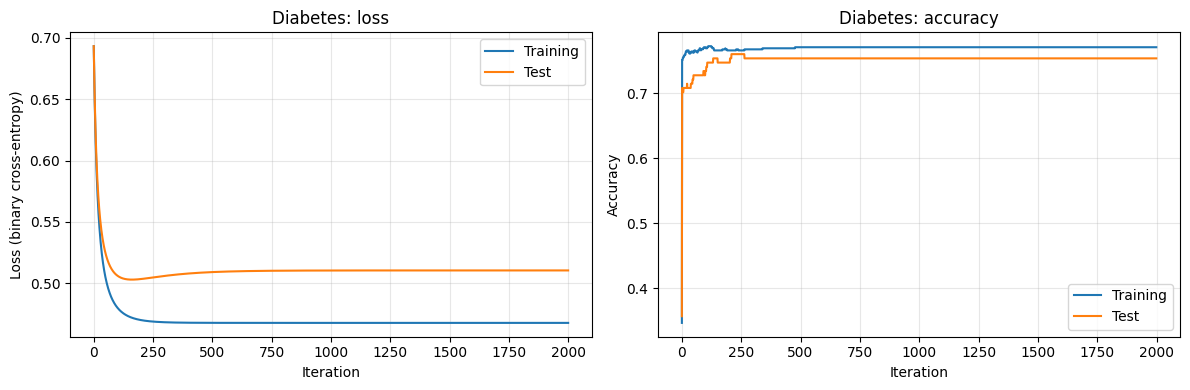

In [7]:
plot_training(hist_d, 'Diabetes')

In [8]:
yp_d = predict(Xte_s, theta_d)
res_d = report(yte, yp_d)
for k, v in res_d.items():
    print(f'{k:<10} {v:.4f}')

Accuracy   0.7532
Precision  0.6491
Recall     0.6727
F1 score   0.6607


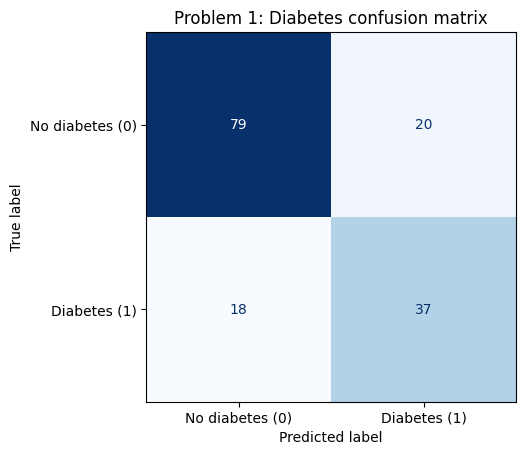

[[79 20]
 [18 37]]


In [9]:
cm_d = plot_cm(yte, yp_d, ['No diabetes (0)', 'Diabetes (1)'], 'Problem 1: Diabetes confusion matrix')
print(cm_d)

---
# Problem 2: Breast cancer dataset (30 features)

In `load_breast_cancer`, 0 = malignant and 1 = benign. The labels are flipped so that
**malignant = 1** is the positive class, since detecting malignant cases is the goal.

In [13]:
cancer = load_breast_cancer()
Xc = cancer.data
yc = 1 - cancer.target                     # 1 = malignant, 0 = benign
print(Xc.shape, '  malignant:', yc.sum(), '  benign:', (yc == 0).sum())

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=SEED)
sc_c = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_te_s = sc_c.transform(Xc_tr), sc_c.transform(Xc_te)
print('training:', Xc_tr_s.shape, '  test:', Xc_te_s.shape)

(569, 30)   malignant: 212   benign: 357
training: (455, 30)   test: (114, 30)


## Problem 2.1: No weight penalty

In [15]:
theta_c, hist_c = train_logistic(Xc_tr_s, yc_tr, Xc_te_s, yc_te, lam=0.0)
print('Final training loss:', round(hist_c['train_loss'][-1], 4), '  test loss:', round(hist_c['test_loss'][-1], 4))
print('Final training accuracy:', round(hist_c['train_acc'][-1], 4), '  test accuracy:', round(hist_c['test_acc'][-1], 4))
print('Sum of squared weights:', round(np.sum(theta_c[1:] ** 2), 2))

Final training loss: 0.0544   test loss: 0.0552
Final training accuracy: 0.9868   test accuracy: 0.9912
Sum of squared weights: 15.09


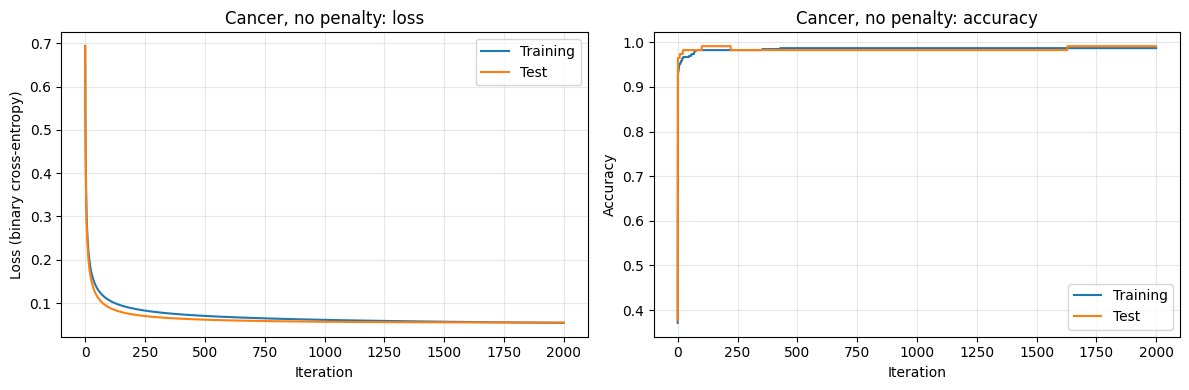

In [16]:
plot_training(hist_c, 'Cancer, no penalty')

In [18]:
yp_c = predict(Xc_te_s, theta_c)
res_c = report(yc_te, yp_c)
for k, v in res_c.items():
    print(f'{k:<10} {v:.4f}')

Accuracy   0.9912
Precision  1.0000
Recall     0.9767
F1 score   0.9882


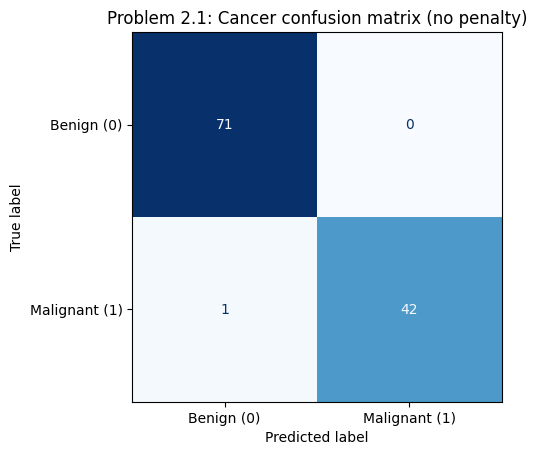

[[71  0]
 [ 1 42]]


In [19]:
cm_c = plot_cm(yc_te, yp_c, ['Benign (0)', 'Malignant (1)'], 'Problem 2.1: Cancer confusion matrix (no penalty)')
print(cm_c)

## Problem 2.2: Adding an L2 weight penalty

The model has 31 parameters for 455 training samples, so an L2 penalty is added to keep the weights small.
Several values of $\lambda$ are tried first to see the effect.

In [20]:
rows = []
for lam in [0, 0.1, 1, 10, 100]:
    th, h = train_logistic(Xc_tr_s, yc_tr, Xc_te_s, yc_te, lam=lam)
    r = report(yc_te, predict(Xc_te_s, th))
    rows.append({'lambda': lam, 'Train acc': h['train_acc'][-1], **r,
                 'Sum theta^2': np.sum(th[1:] ** 2)})
sweep = pd.DataFrame(rows).round(4)
sweep

,lambda,Train acc,Accuracy,Precision,Recall,F1 score,Sum theta^2
0,0.0,0.9868,0.9912,1.0,0.9767,0.9882,15.0911
1,0.1,0.9868,0.9912,1.0,0.9767,0.9882,14.5453
2,1.0,0.9868,0.9912,1.0,0.9767,0.9882,10.8706
3,10.0,0.9802,0.9825,1.0,0.9535,0.9762,3.3592
4,100.0,0.9560,0.9649,1.0,0.9070,0.9512,0.6887


In [21]:
LAM = 1.0
theta_r, hist_r = train_logistic(Xc_tr_s, yc_tr, Xc_te_s, yc_te, lam=LAM)
print('lambda =', LAM)
print('Final training loss (with penalty):', round(hist_r['train_loss'][-1], 4), '  test loss:', round(hist_r['test_loss'][-1], 4))
print('Final training accuracy:', round(hist_r['train_acc'][-1], 4), '  test accuracy:', round(hist_r['test_acc'][-1], 4))
print('Sum of squared weights:', round(np.sum(theta_r[1:] ** 2), 2), ' (no penalty:', round(np.sum(theta_c[1:] ** 2), 2), ')')

lambda = 1.0
Final training loss (with penalty): 0.0709   test loss: 0.058
Final training accuracy: 0.9868   test accuracy: 0.9912
Sum of squared weights: 10.87  (no penalty: 15.09 )


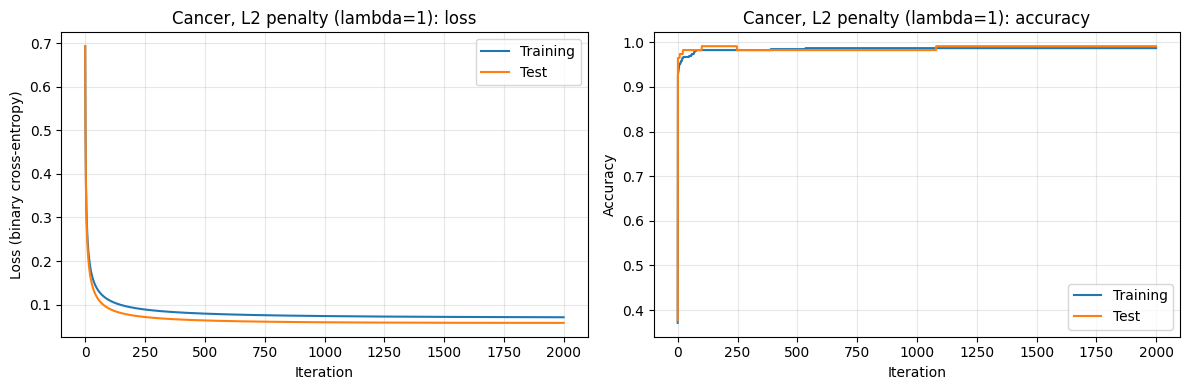

In [22]:
plot_training(hist_r, f'Cancer, L2 penalty (lambda={LAM:g})')

In [23]:
yp_r = predict(Xc_te_s, theta_r)
res_r = report(yc_te, yp_r)
print(pd.DataFrame({'No penalty': res_c, f'L2, lambda={LAM:g}': res_r}).round(4))

           No penalty  L2, lambda=1
Accuracy       0.9912        0.9912
Precision      1.0000        1.0000
Recall         0.9767        0.9767
F1 score       0.9882        0.9882


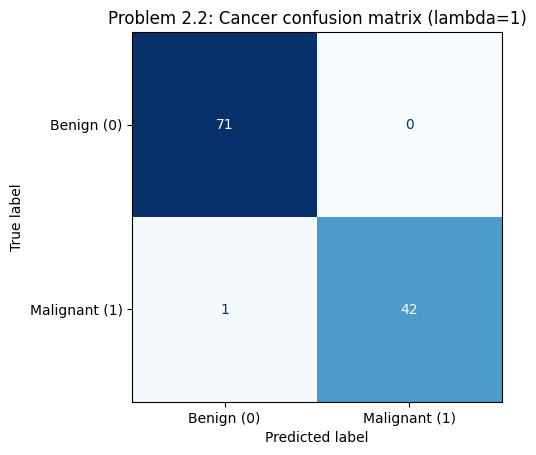

[[71  0]
 [ 1 42]]


In [24]:
cm_r = plot_cm(yc_te, yp_r, ['Benign (0)', 'Malignant (1)'], f'Problem 2.2: Cancer confusion matrix (lambda={LAM:g})')
print(cm_r)

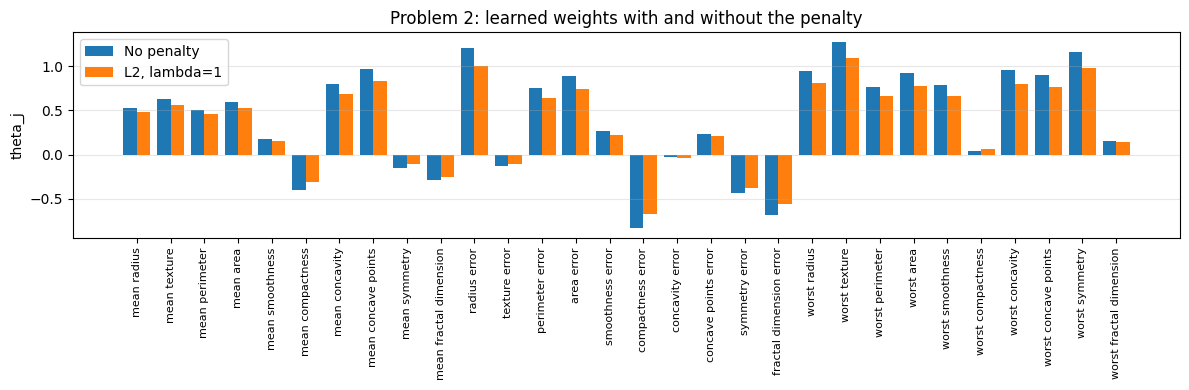

In [25]:
# Weights with and without the penalty
idx = np.arange(30)
plt.figure(figsize=(12, 4))
plt.bar(idx - 0.2, theta_c[1:], width=0.4, label='No penalty')
plt.bar(idx + 0.2, theta_r[1:], width=0.4, label=f'L2, lambda={LAM:g}')
plt.xticks(idx, cancer.feature_names, rotation=90, fontsize=8)
plt.ylabel('theta_j'); plt.title('Problem 2: learned weights with and without the penalty')
plt.legend(); plt.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()